# 01 — Exploring the dataset

**Why this notebook exists.** Before modeling, you always look at the data.
Wrong assumptions about gaps, missing values, distributions, or column
meanings are the #1 cause of ML projects that look great in training and
collapse in production.

We answer four questions here:
1. What's in the file (shape, date range, columns)?
2. Does the price series look sane?
3. Are there gaps or duplicate timestamps?
4. Where are NaNs concentrated — is it real missing data or just
   warmup periods for slow indicators?


## Load shared helpers

`%run` literally re-executes `00_setup.ipynb` in the current kernel, so all
the functions (`load_dataset`, `add_derived_features`, …) are now in scope.


In [1]:
%run 00_setup.ipynb

loaders ready: load_dataset drop_indicator_warmup add_derived_features label_regression label_classification feature_columns


## 1.1 — What's in the file?

`load_dataset()` returns a `DataFrame`. `.shape` is `(rows, columns)`.
`.head(3)` shows the first three rows. We expect:
- ~2400 rows (one per day, May 2019 → Dec 2025)
- ~46 columns (58 original − stale flags − ETF after the defaults drop them)
- Sorted ascending by `timestamp`


In [2]:
df = load_dataset()
print("shape:", df.shape)
print("range:", df["timestamp"].min(), "→", df["timestamp"].max())
print("columns kept:", df.shape[1])
df.head(3)


shape: (2437, 47)
range: 2019-05-01 00:00:00+00:00 → 2025-12-31 00:00:00+00:00
columns kept: 47


,timestamp,symbol,interval,open,high,low,close,volume,ad_line,adx,...,difficulty,block_time,miner_reserves,miner_outflows,mpi,exchange_inflow,exchange_outflow,exchange_reserves,events_in_window,high_impact_events_in_window
0,2019-05-01 00:00:00+00:00,BTCUSDT,1d,5321.94,5402.0,5316.20,5383.20,17217.473216,365624.215483,51.055880,...,6.353031e+12,1.126911,1353.605919,1329.263116,1115.734191,1451.127856,1335.533451,1003.562354,0,0
1,2019-05-02 00:00:00+00:00,BTCUSDT,1d,5383.20,5538.0,5370.00,5492.87,22795.787835,376172.694925,50.082606,...,6.353031e+12,1.100862,1425.533075,1152.939743,1466.379278,1037.264739,1269.430583,1033.789352,0,0
2,2019-05-03 00:00:00+00:00,BTCUSDT,1d,5494.81,5844.0,5477.57,5772.69,46297.172849,404450.320270,50.277769,...,6.353031e+12,1.228200,1350.781118,1441.275209,1050.249221,1410.162999,1096.952925,1103.896592,0,0


## 1.2 — Does the price series look like Bitcoin?

We plot the closing price over the whole window. **Log scale** on the y-axis
is the right choice for crypto/equities: price grows multiplicatively (a
50% rally at $10k = $5k move; same rally at $100k = $50k move). On linear
scale recent moves dwarf early ones; on log scale a constant rate of growth
becomes a straight line, and percentage moves are visually consistent.

What to look for:
- 2019-2020: ~$5k-$10k range, COVID crash in March 2020 is visible.
- 2020-2021: explosive bull run to $69k.
- 2022: ~$15k bear bottom.
- 2023-2024: recovery and ETF approval rally.
- 2025: above $80k.

If the line looks wrong (huge spike to zero, missing chunks, flat for months)
the CSV is corrupted.


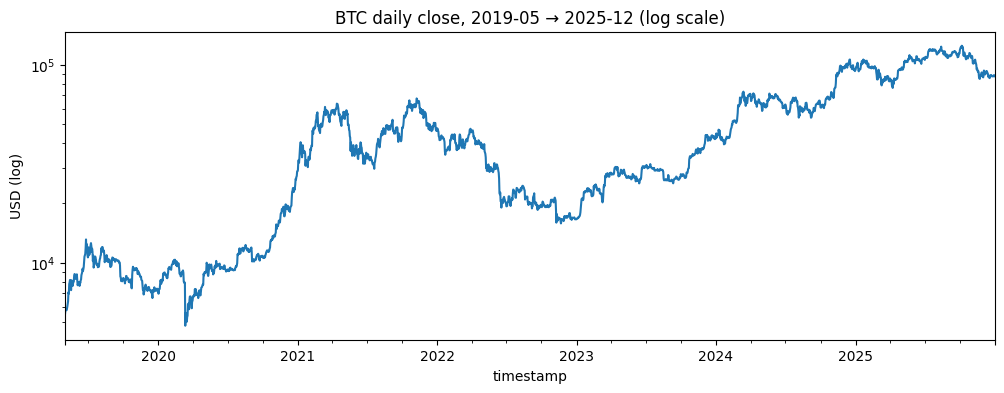

In [3]:
df.set_index("timestamp")["close"].plot(
    title="BTC daily close, 2019-05 → 2025-12 (log scale)",
    logy=True,
)
plt.ylabel("USD (log)")
plt.show()


## 1.3 — Gaps and duplicates

We expect **exactly one row per day**.
- `diff()` on the timestamp column gives the spacing between consecutive rows.
- We divide by 86400 (seconds in a day) to convert to days.
- If anything ≠ 1, we have a gap or duplicate.

`duplicated()` checks for repeat timestamps. Any > 0 = bug in the upstream
data service, must investigate before training.


In [4]:
gaps = df["timestamp"].diff().dt.total_seconds() / 86400
print("non-1d gaps:", (gaps.dropna() != 1).sum())
print("duplicate timestamps:", df["timestamp"].duplicated().sum())


non-1d gaps: 0
duplicate timestamps: 0


## 1.4 — NaN audit

`isna().sum()` counts missing values per column. We sort descending and show
the top 10. Three common patterns to recognize:

- **Slow indicators on the first ~200-365 rows.** Ichimoku `senkou_b` needs
  52 weeks, EMA200 needs 200 days. These NaNs are *expected* and handled by
  `drop_indicator_warmup()` in notebook 02.
- **Alt-data NaNs after backfill cutoff.** If the dataset-service couldn't
  fetch a given metric for a date, that cell is NaN. Forward-fill handles
  short gaps; long gaps mean drop the feature.
- **All-zero columns.** Not NaN, but useless. The `*_age_hours` columns
  are like this (constant 0). We already drop them in `load_dataset()`.


In [5]:
nans = df.isna().sum().sort_values(ascending=False)
print("top NaN columns:")
print(nans[nans > 0].head(10) if (nans > 0).any() else "no NaNs after default drops")


top NaN columns:
difficulty    30
hash_rate     30
block_time    30
dtype: int64
